# EX_03 — Two-Digit Obfuscation at 128x128

**Epic:** 2 | **Date:** 2026-04-26 | **Owner:** tanmay

## Context
Extends Epic 2 to the two-digit case. Each 128x128 composite embeds two MNIST digits at random non-overlapping positions. Goal: learn a mask that hides both digits pre-blur and recovers both post-blur.

**Key fix over Epic 2 EX_01 and EX_02:** classifier is trained and evaluated on 28x28 crops extracted at tracked digit positions — not on a downsampled full image. That broken oracle is why EX_01/EX_02 plateaued at 0.12 accuracy.

## Hypothesis
With a working crop-based oracle and two-digit delta-VIS loss, a UNet learned mask (B) can achieve a meaningful negative conf delta vs the random baseline (A).

In [1]:
!pip install wandb -q

In [2]:
# Uncomment to persist models across Colab sessions via Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# import os; os.makedirs('/content/drive/MyDrive/blur_obfuscation/Epic_2/EX_03', exist_ok=True)

In [3]:
import os, random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision
from torchvision import datasets, transforms
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [4]:
for folder in ['Model/A', 'Model/B', 'Raw/gradients', 'Results/Graphs', 'logs/A', 'logs/B', 'data']:
    os.makedirs(folder, exist_ok=True)

torchvision.datasets.MNIST('./data/', train=True,  download=True)
torchvision.datasets.MNIST('./data/', train=False, download=True)
print('Folders created, MNIST downloaded')

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.4MB/s]


Folders created, MNIST downloaded


In [5]:
IMAGE_SIZE      = 128
DIGIT_SIZE      = 28
BOX_BLUR_KERNEL = max(3, int(9 * IMAGE_SIZE / DIGIT_SIZE)) | 1   # 41
BATCH_SIZE      = 32
LR              = 1e-3
SEED            = 42
ALPHA           = -0.55
BETA            = 0.45
NUM_GRADIENTS   = 1000
NUM_PAIRS       = 5000

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'IMAGE_SIZE      = {IMAGE_SIZE}')
print(f'BOX_BLUR_KERNEL = {BOX_BLUR_KERNEL}')
print(f'BATCH_SIZE      = {BATCH_SIZE}')
print(f'ALPHA           = {ALPHA}')
print(f'BETA            = {BETA}')

IMAGE_SIZE      = 128
BOX_BLUR_KERNEL = 41
BATCH_SIZE      = 32
ALPHA           = -0.55
BETA            = 0.45


In [6]:
GRAD_DIR = Path('Raw/gradients')
CSV_PATH = Path('Raw/pairings_2digit.csv')

if not CSV_PATH.exists():
    grad_paths = []
    for i in range(NUM_GRADIENTS):
        c1  = np.random.randint(0, 256, 3)
        c2  = np.random.randint(0, 256, 3)
        img = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)
        for row in range(IMAGE_SIZE):
            t = row / (IMAGE_SIZE - 1)
            img[row] = (c1 * (1 - t) + c2 * t).astype(np.uint8)
        path = str(GRAD_DIR / f'grad_{i:04d}.png')
        Image.fromarray(img).save(path)
        grad_paths.append(path)

    mnist_all = datasets.MNIST('./data/', train=True, download=False)
    N = len(mnist_all)
    rows = []
    for _ in range(NUM_PAIRS):
        g  = random.randint(0, NUM_GRADIENTS - 1)
        d1 = random.randint(0, N - 1)
        d2 = random.randint(0, N - 1)
        while d2 == d1:
            d2 = random.randint(0, N - 1)
        rows.append({'gradient_path': grad_paths[g], 'digit_1_idx': d1, 'digit_2_idx': d2})

    pd.DataFrame(rows).to_csv(CSV_PATH, index=False)
    print(f'Generated {NUM_GRADIENTS} gradients, {NUM_PAIRS} 2-digit pairings')
    print(pd.read_csv(CSV_PATH).head())
else:
    print('Data already exists, skipping generation')

Generated 1000 gradients, 5000 2-digit pairings
                 gradient_path  digit_1_idx  digit_2_idx
0  Raw/gradients/grad_0654.png         7296         1639
1  Raw/gradients/grad_0759.png        18024        16049
2  Raw/gradients/grad_0228.png         9144        48265
3  Raw/gradients/grad_0104.png        44348        48540
4  Raw/gradients/grad_0913.png        35741         5697


In [7]:
class LeNet3channel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1   = nn.Linear(16 * 5 * 5, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 10)

    def forward(self, x):
        x = F.avg_pool2d(F.relu(self.conv1(x)), 2)
        x = F.avg_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.size(0), -1)
        return self.fc3(F.relu(self.fc2(F.relu(self.fc1(x)))))


def embed_2_digits(d1, d2, bg, margin=4):
    _, H, W = bg.shape
    dh = dw = DIGIT_SIZE
    for _ in range(100):
        y1 = random.randint(0, H - dh)
        x1 = random.randint(0, W - dw)
        y2 = random.randint(0, H - dh)
        x2 = random.randint(0, W - dw)
        if not (abs(y1 - y2) < dh + margin and abs(x1 - x2) < dw + margin):
            break
    canvas = torch.zeros(1, H, W)
    canvas[:, y1:y1 + dh, x1:x1 + dw] = d1
    canvas[:, y2:y2 + dh, x2:x2 + dw] = d2
    comp      = (bg + canvas.expand(3, H, W)).clamp(0, 1)
    positions = torch.tensor([[y1, x1], [y2, x2]], dtype=torch.long)
    return comp, positions


class TwoDigitDataset(Dataset):
    def __init__(self, csv_path):
        self.pairings = pd.read_csv(csv_path)
        self.bg_tf = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
        ])
        self.mnist = datasets.MNIST('./data/', train=True, download=False,
                                    transform=transforms.ToTensor())

    def __len__(self):
        return len(self.pairings)

    def __getitem__(self, idx):
        ann      = self.pairings.iloc[idx]
        bg       = self.bg_tf(Image.open(ann['gradient_path']).convert('RGB'))
        d1, lab1 = self.mnist[int(ann['digit_1_idx'])]
        d2, lab2 = self.mnist[int(ann['digit_2_idx'])]
        comp, positions = embed_2_digits(d1, d2, bg)
        labels = torch.tensor([lab1, lab2], dtype=torch.long)
        return comp, labels, positions

print('LeNet3channel, embed_2_digits, TwoDigitDataset defined')

LeNet3channel, embed_2_digits, TwoDigitDataset defined


Dataset: 5000 total (4500 train / 500 val)
comp: torch.Size([3, 128, 128]), labels: [4, 7], positions: [[62, 86], [97, 12]]


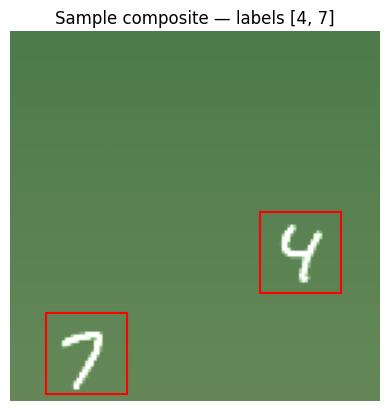

In [8]:
full_dataset = TwoDigitDataset(CSV_PATH)
n = len(full_dataset)
train_size = int(0.9 * n)
val_size   = n - train_size

train_set, val_set = random_split(full_dataset, [train_size, val_size],
                                  generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)

comp, labels, positions = full_dataset[0]
print(f'Dataset: {len(full_dataset)} total ({train_size} train / {val_size} val)')
print(f'comp: {comp.shape}, labels: {labels.tolist()}, positions: {positions.tolist()}')

plt.imshow(comp.permute(1, 2, 0).clamp(0, 1))
plt.title(f'Sample composite — labels {labels.tolist()}')
for (y, x) in positions.tolist():
    plt.gca().add_patch(plt.Rectangle((x, y), DIGIT_SIZE, DIGIT_SIZE,
                                       linewidth=1.5, edgecolor='red', facecolor='none'))
plt.axis('off')
plt.show()

In [9]:
def train_model(model, optimizer, loss_fn, train_loader, val_loader, epochs, name):
    has_params = any(p.requires_grad for p in model.parameters())
    if not has_params:
        print(f'[{name}] no trainable parameters, skipping training')
        return model

    model.to(device)

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for batch in tqdm(train_loader, desc=f'[{name}] epoch {epoch}/{epochs}', leave=False):
            batch = [b.to(device) if isinstance(b, torch.Tensor) else b for b in batch]
            optimizer.zero_grad()
            loss = loss_fn(batch, model, mode='train')
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_results = []
        with torch.no_grad():
            for batch in val_loader:
                batch = [b.to(device) if isinstance(b, torch.Tensor) else b for b in batch]
                result = loss_fn(batch, model, mode='val')
                val_results.append(result)

        avg_train = np.mean(train_losses)
        avg_val   = np.mean([r['val_loss']  for r in val_results])
        avg_pre   = np.mean([r['conf_pre']  for r in val_results])
        avg_post  = np.mean([r['conf_post'] for r in val_results])

        print(f'  Epoch {epoch}/{epochs}: train={avg_train:.4f} | val={avg_val:.4f} | conf_pre={avg_pre:.4f} | conf_post={avg_post:.4f}')

    return model

In [10]:
# Train classifier on 28x28 crops — fixes the downsampling oracle bug from Epic 2 EX_01 and EX_02
b_model = LeNet3channel().to(device)
opt_clf = torch.optim.Adam(b_model.parameters(), lr=LR)

CLASSIFIER_EPOCHS = 5
print(f'Training classifier for {CLASSIFIER_EPOCHS} epochs...')

for epoch in range(1, CLASSIFIER_EPOCHS + 1):
    b_model.train()
    total_loss = correct = total = 0

    for comps, labels, positions in tqdm(train_loader, desc=f'Classifier epoch {epoch}/{CLASSIFIER_EPOCHS}', leave=False):
        comps, labels, positions = comps.to(device), labels.to(device), positions.to(device)
        B = comps.shape[0]

        # extract 2 crops per image -> 2B training examples
        crops, labs = [], []
        for b in range(B):
            for d in range(2):
                y = positions[b, d, 0].item()
                x = positions[b, d, 1].item()
                crops.append(comps[b:b+1, :, y:y + DIGIT_SIZE, x:x + DIGIT_SIZE])
                labs.append(labels[b, d])
        crops = torch.cat(crops, dim=0)
        labs  = torch.stack(labs)

        opt_clf.zero_grad()
        logits = b_model(crops)
        loss   = nn.CrossEntropyLoss()(logits, labs)
        loss.backward()
        opt_clf.step()

        total_loss += loss.item() * crops.size(0)
        correct    += (logits.argmax(1) == labs).sum().item()
        total      += crops.size(0)

    print(f'  Epoch {epoch}: loss={total_loss / total:.4f}, acc={correct / total:.4f}')

torch.save(b_model.state_dict(), 'Model/B/classifier_final.pt')
for p in b_model.parameters():
    p.requires_grad = False
b_model.eval()
print('Classifier trained and frozen')

Training classifier for 5 epochs...


Classifier epoch 1/5:   0%|          | 0/141 [00:00<?, ?it/s]

  Epoch 1: loss=1.3759, acc=0.5332


Classifier epoch 2/5:   0%|          | 0/141 [00:00<?, ?it/s]

  Epoch 2: loss=0.4668, acc=0.8563


...

  Epoch 3: loss=0.3415, acc=0.8956


Classifier epoch 4/5:   0%|          | 0/141 [00:00<?, ?it/s]

  Epoch 4: loss=0.2846, acc=0.9136


Classifier epoch 5/5:   0%|          | 0/141 [00:00<?, ?it/s]

  Epoch 5: loss=0.2296, acc=0.9279
Classifier trained and frozen


In [23]:
def box_blur(x, kernel_size=BOX_BLUR_KERNEL):
    C = x.shape[1]
    k = torch.ones(C, 1, kernel_size, kernel_size, device=x.device) / (kernel_size ** 2)
    return F.conv2d(x, k, padding=kernel_size // 2, groups=C)


def crop_and_classify(imgs, positions, labels):
    B = imgs.shape[0]
    crops, labs = [], []
    for b in range(B):
        for d in range(2):
            y = positions[b, d, 0].item()
            x = positions[b, d, 1].item()
            crops.append(imgs[b:b+1, :, y:y + DIGIT_SIZE, x:x + DIGIT_SIZE])
            labs.append(labels[b, d])
    crops = torch.cat(crops, dim=0)
    labs  = torch.stack(labs)
    logits = b_model(crops)
    preds  = torch.softmax(logits, dim=1)
    confs  = preds[torch.arange(2 * B, device=imgs.device), labs].view(B, 2).mean(dim=1)
    pred_labels = logits.argmax(1).view(B, 2)
    return confs, pred_labels


ACTIVITY_THRESHOLD = 0.3
ACTIVITY_LAMBDA    = 2.0   # raised from 0.5 — must dominate the delta_vis collapse


def delta_vis_loss(batch, model, mode='train', **kwargs):
    comp, labels, positions = batch
    masked    = model(comp)
    conf_pre,  _ = crop_and_classify(masked,  positions, labels)
    blurred   = box_blur(masked)
    conf_post, _ = crop_and_classify(blurred, positions, labels)
    delta_vis = ALPHA * conf_pre + BETA * conf_post
    activity_loss = F.relu(ACTIVITY_THRESHOLD - masked.mean())
    loss = (-delta_vis).mean() + ACTIVITY_LAMBDA * activity_loss
    if mode == 'val':
        return {
            'val_loss':      loss.item(),
            'conf_pre':      conf_pre.mean().item(),
            'conf_post':     conf_post.mean().item(),
            'delta_vis':     delta_vis.mean().item(),
            'activity_loss': activity_loss.item(),
        }
    return loss

print('box_blur, crop_and_classify, delta_vis_loss defined')

box_blur, crop_and_classify, delta_vis_loss defined


In [24]:
# Variation A — RandomMask baseline
class RandomMask(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.p = dropout_rate

    def forward(self, x):
        mask = (torch.rand_like(x) > self.p).float()
        return x * mask

model_a   = RandomMask(dropout_rate=0.5).to(device)
opt_a     = torch.optim.Adam([torch.zeros(1, requires_grad=True)], lr=LR)

model_a = train_model(model_a, opt_a, delta_vis_loss, train_loader, val_loader,
                      epochs=3, name='Variation A (Random Mask)')

torch.save(model_a.state_dict(), 'Model/A/random_mask_final.pt')

[Variation A (Random Mask)] no trainable parameters, skipping training


In [25]:
# Variation B — UNet learned mask
class LearnedMask(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
        )
        self.pool = nn.MaxPool2d(2)
        self.up2  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
        )
        self.up1  = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
        )
        self.out_conv = nn.Conv2d(32, 3, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        d2 = self.up2(e3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        # mask in [0.1, 1.0] — never fully black, gradient always flows through sigmoid
        mask = 0.1 + 0.9 * torch.sigmoid(self.out_conv(d1))
        return (x * mask).clamp(0, 1)


model_b   = LearnedMask().to(device)
opt_b_msk = torch.optim.Adam(model_b.parameters(), lr=LR)

model_b = train_model(model_b, opt_b_msk, delta_vis_loss, train_loader, val_loader,
                      epochs=10, name='Variation B (UNet Mask)')

torch.save(model_b.state_dict(), 'Model/B/unet_mask_final.pt')

[Variation B (UNet Mask)] epoch 1/10:   0%|          | 0/141 [00:00<?, ?it/s]

  Epoch 1/10: train=0.0828 | val=-0.0404 | conf_pre=0.0044 | conf_post=0.0951


[Variation B (UNet Mask)] epoch 2/10:   0%|          | 0/141 [00:00<?, ?it/s]

  Epoch 2/10: train=-0.0365 | val=-0.0418 | conf_pre=0.0032 | conf_post=0.0968


[Variation B (UNet Mask)] epoch 3/10:   0%|          | 0/141 [00:00<?, ?it/s]

...

  Epoch 8/10: train=-0.0796 | val=-0.0781 | conf_pre=0.0011 | conf_post=0.1749


[Variation B (UNet Mask)] epoch 9/10:   0%|          | 0/141 [00:00<?, ?it/s]

  Epoch 9/10: train=-0.0868 | val=-0.0869 | conf_pre=0.0021 | conf_post=0.1956


[Variation B (UNet Mask)] epoch 10/10:   0%|          | 0/141 [00:00<?, ?it/s]

  Epoch 10/10: train=-0.0937 | val=-0.0962 | conf_pre=0.0025 | conf_post=0.2169


In [26]:
def run_eval(model, loader, name):
    print(f'\n{"="*60}')
    print(f'Evaluating: {name}')
    print('=' * 60)

    model.eval()
    pre_list, post_list = [], []

    with torch.no_grad():
        for comps, labels, positions in tqdm(loader, desc=f'Eval {name}', leave=False):
            comps, labels, positions = comps.to(device), labels.to(device), positions.to(device)
            masked  = model(comps)
            blurred = box_blur(masked)
            cpre,  _ = crop_and_classify(masked,  positions, labels)
            cpost, _ = crop_and_classify(blurred, positions, labels)
            pre_list.extend(cpre.cpu().numpy())
            post_list.extend(cpost.cpu().numpy())

    pre  = np.array(pre_list)
    post = np.array(post_list)
    print(f'  mean conf pre : {pre.mean():.4f}')
    print(f'  mean conf post: {post.mean():.4f}')
    print(f'  conf delta    : {(post - pre).mean():+.4f}')

    df = pd.DataFrame({'conf_pre': pre, 'conf_post': post})
    df.to_csv(f'Results/{name}_preds.csv', index=False)
    return df


df_a = run_eval(model_a, val_loader, 'A_random')
df_b = run_eval(model_b, val_loader, 'B_unet')


Evaluating: A_random


Eval A_random:   0%|          | 0/16 [00:00<?, ?it/s]

  mean conf pre : 0.6217
  mean conf post: 0.1021
  conf delta    : -0.5196

Evaluating: B_unet


Eval B_unet:   0%|          | 0/16 [00:00<?, ?it/s]

  mean conf pre : 0.0018
  mean conf post: 0.2203
  conf delta    : +0.2186


Random Mask examples:


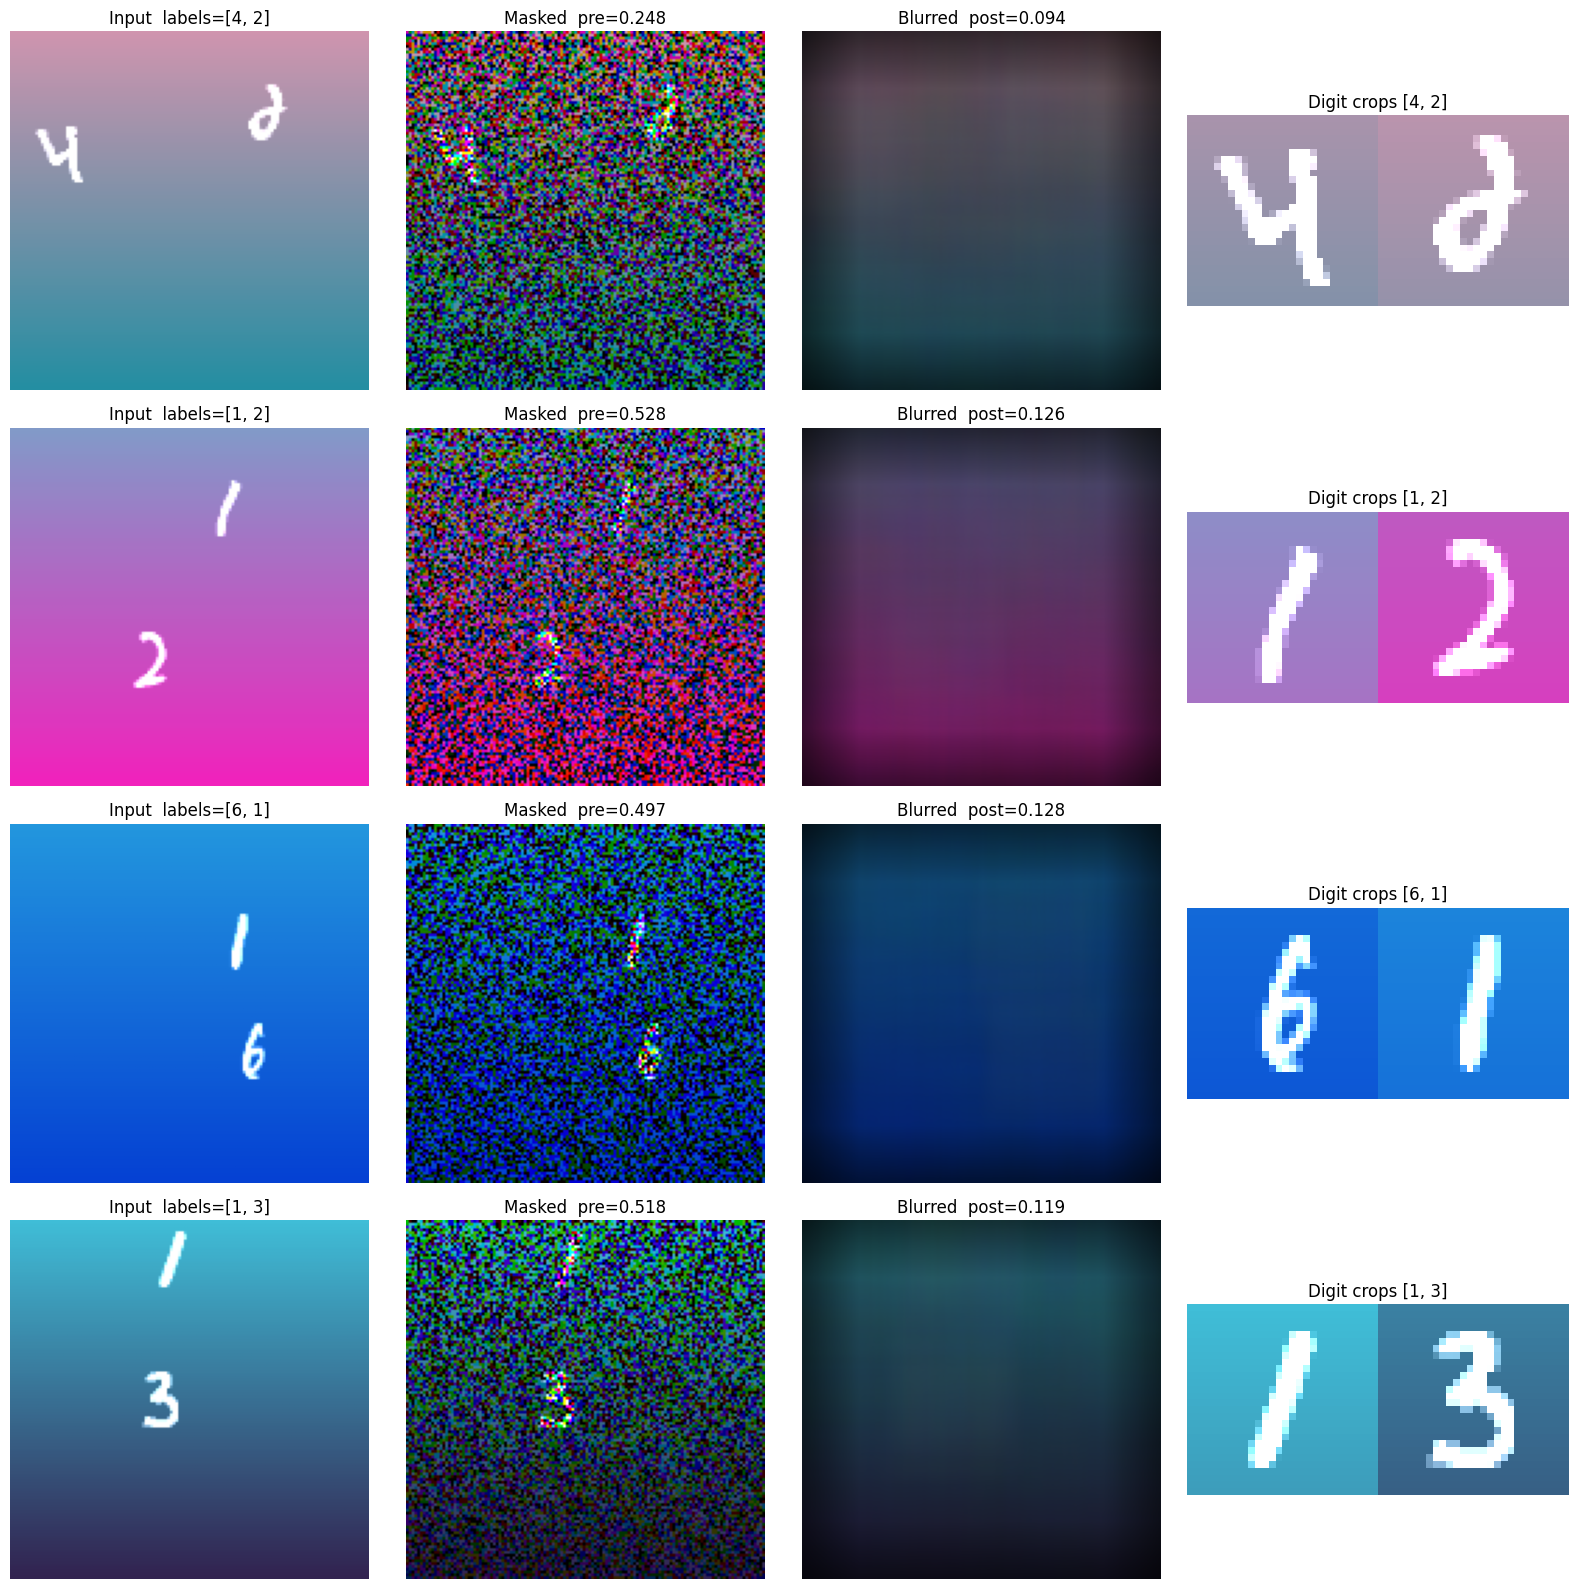

UNet Mask examples:


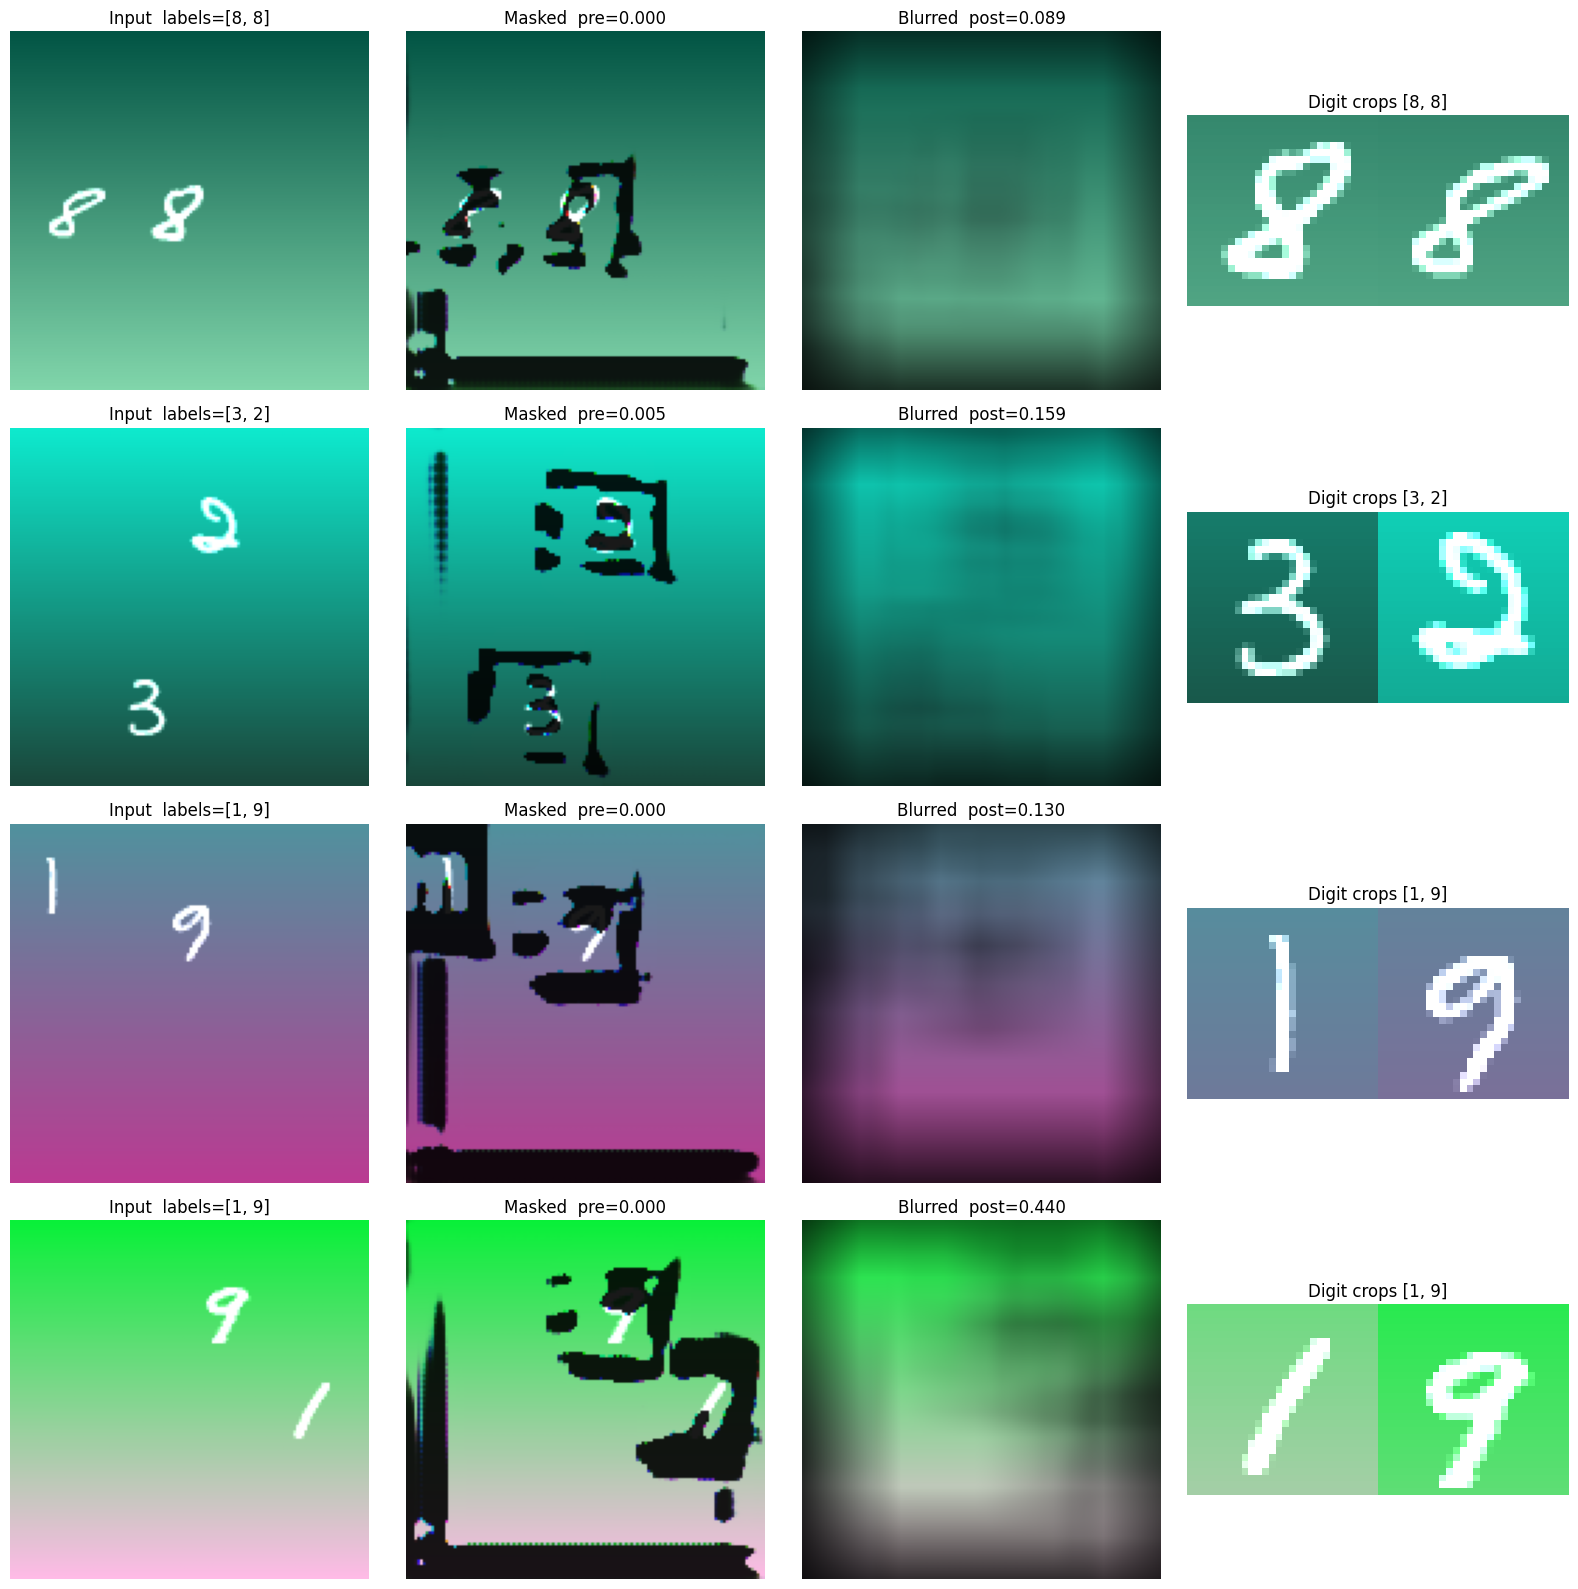

In [27]:
def show_examples(model, dataset, name, n=4):
    model.eval()
    fig, axes = plt.subplots(n, 4, figsize=(16, n * 4))
    for row in range(n):
        comp, labels, positions = dataset[random.randint(0, len(dataset) - 1)]
        c_in = comp.unsqueeze(0).to(device)
        p_in = positions.unsqueeze(0).to(device)
        l_in = labels.unsqueeze(0).to(device)
        with torch.no_grad():
            masked  = model(c_in)
            blurred = box_blur(masked)
            cpre,  _ = crop_and_classify(masked,  p_in, l_in)
            cpost, _ = crop_and_classify(blurred, p_in, l_in)
        def to_img(t):
            return t.squeeze(0).cpu().permute(1, 2, 0).clamp(0, 1).numpy()
        y1, x1 = positions[0].tolist()
        y2, x2 = positions[1].tolist()
        crop1 = comp[:, y1:y1 + DIGIT_SIZE, x1:x1 + DIGIT_SIZE]
        crop2 = comp[:, y2:y2 + DIGIT_SIZE, x2:x2 + DIGIT_SIZE]
        axes[row, 0].imshow(to_img(c_in))
        axes[row, 0].set_title(f'Input  labels={labels.tolist()}')
        axes[row, 1].imshow(to_img(masked))
        axes[row, 1].set_title(f'Masked  pre={cpre.item():.3f}')
        axes[row, 2].imshow(to_img(blurred))
        axes[row, 2].set_title(f'Blurred  post={cpost.item():.3f}')
        axes[row, 3].imshow(torch.cat([crop1, crop2], dim=2).permute(1, 2, 0).clamp(0, 1).numpy())
        axes[row, 3].set_title(f'Digit crops {labels.tolist()}')
        for ax in axes[row]:
            ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'Results/Graphs/{name}_samples.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Random Mask examples:')
show_examples(model_a, full_dataset, 'A_random')
print('UNet Mask examples:')
show_examples(model_b, full_dataset, 'B_unet')

In [1]:
import shutil
from google.colab import files

EXP_NAME = 'EX_03_results'
shutil.make_archive(f'/content/{EXP_NAME}', 'zip', '.')
files.download(f'/content/{EXP_NAME}.zip')
print(f'Downloading {EXP_NAME}.zip — check your browser downloads folder')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>